In [ ]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
import kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

First, let's define the paths to the training, validation, and test directories within the downloaded dataset.

In [ ]:
train_dir = os.path.join(path, 'chest_xray', 'train')
val_dir = os.path.join(path, 'chest_xray', 'val')
test_dir = os.path.join(path, 'chest_xray', 'test')

print(f"Train directory: {train_dir}")
print(f"Validation directory: {val_dir}")
print(f"Test directory: {test_dir}")

Train directory: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Validation directory: /kaggle/input/chest-xray-pneumonia/chest_xray/val
Test directory: /kaggle/input/chest-xray-pneumonia/chest_xray/test


Now, I'll load the images using `image_dataset_from_directory`. This utility automatically infers the labels from the directory names and handles common preprocessing steps like resizing.

In [ ]:
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Class names: ['NORMAL', 'PNEUMONIA']


Let's visualize a few images from the training dataset to understand what we're working with.

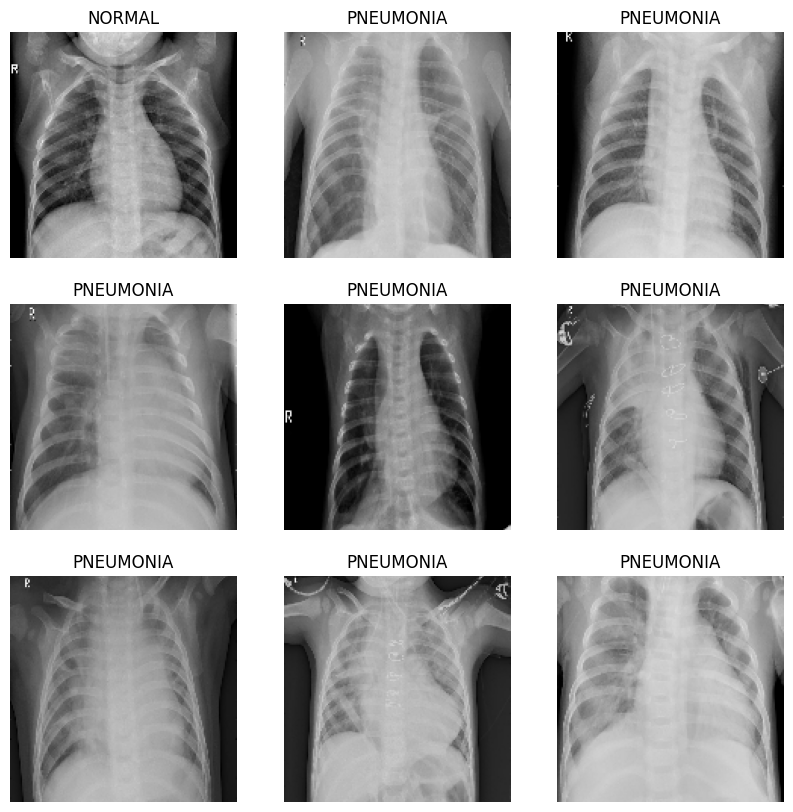

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

Now that the data is loaded and verified, we can proceed with further preprocessing, building a model, and training it for classification.

### Data Preprocessing and Performance Configuration

To optimize training, we'll normalize the pixel values from `[0, 255]` to `[0, 1]` and configure the datasets for caching and prefetching. This will ensure that data is loaded efficiently without I/O bottlenecks.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    # Normalize images to [0, 1]
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(preprocess).cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets preprocessed and configured for performance.")

Datasets preprocessed and configured for performance.


### Build the Convolutional Neural Network (CNN) Model

Now, let's build a simple CNN model. It will consist of convolutional layers for feature extraction, max-pooling layers for dimensionality reduction, and dense layers for classification. Since this is a binary classification problem (`NORMAL` vs `PNEUMONIA`), the output layer will have a single neuron with a sigmoid activation function.

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

num_classes = len(class_names)

model = Sequential([
    layers.Conv2D(16, 3, padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Use 1 neuron with sigmoid for binary classification
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,049 (10.22 MB)

 Trainable params: 2,678,049 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

The model architecture has been defined. The next step is to compile the model with an optimizer, loss function, and metrics, and then proceed to train it.

### Compile and Train the Model

To prepare the model for training, we need to compile it. For binary classification, `BinaryCrossentropy` is the suitable loss function, and `Adam` is a good general-purpose optimizer. We'll monitor `accuracy` during training.

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


Now, let's train the model using the `train_ds` for training and `val_ds` for validation. We'll train for a few epochs and monitor the training and validation accuracy and loss.

In [ ]:
epochs = 10 # You can adjust the number of epochs

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

print("Model training complete.")

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 56s 299ms/step - accuracy: 0.9080 - loss: 0.2231 - val_accuracy: 0.7500 - val_loss: 0.3735
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9651 - loss: 0.0924 - val_accuracy: 0.7500 - val_loss: 0.3549
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9772 - loss: 0.0677 - val_accuracy: 0.8750 - val_loss: 0.2691
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9808 - loss: 0.0556 - val_accuracy: 0.7500 - val_loss: 0.4956
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9845 - loss: 0.0445 - val_accuracy: 0.8125 - val_loss: 0.4868
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9887 - loss: 0.0351 - val_accuracy: 0.8750 - val_loss: 0.2640
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9887 - loss: 0.0314 - val_accuracy: 0.8125 - val_loss: 0.5719
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9956 - loss: 0.0156 - val_ac

The model has been trained. Next, we should evaluate its performance on the test set and visualize the training history.

### Evaluate Model Performance on Test Set

After training, it's crucial to evaluate the model on the `test_ds` (which the model has not seen during training) to get an unbiased estimate of its generalization performance.

In [ ]:
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.6635 - loss: 4.2478
Test Loss: 4.2478
Test Accuracy: 0.6635


### Visualize Training Results

Let's plot the training and validation accuracy and loss over the epochs to observe the model's learning curve and identify potential overfitting or underfitting.

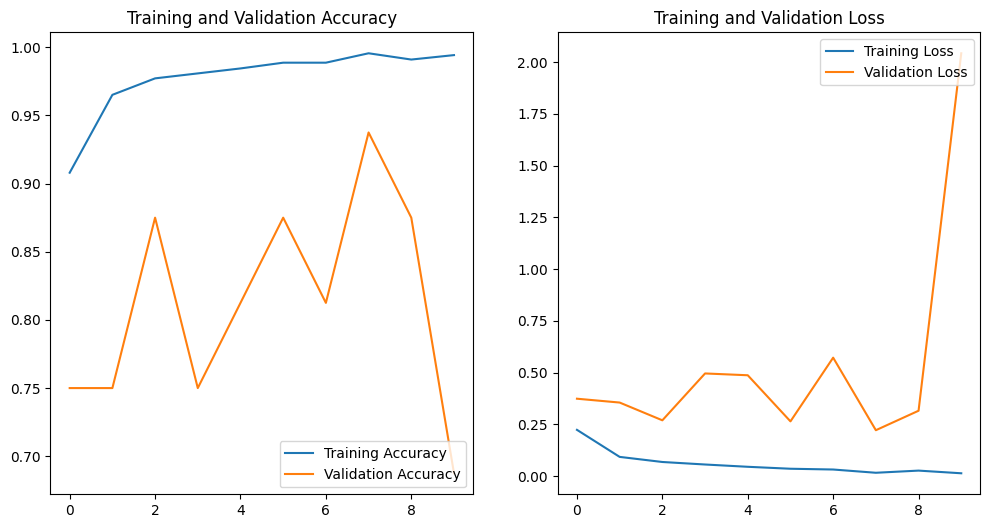

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Summary and Next Steps

We have successfully built, trained, and evaluated a CNN model for classifying chest X-ray images into 'NORMAL' and 'PNEUMONIA'. The evaluation on the test set and the training visualization provide insights into the model's performance.

If you'd like, we can now explore further improvements such as data augmentation, transfer learning, hyperparameter tuning, or making predictions on new images.